**IMPORT LIBRARIES**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.getcwd()

'/content'

**LOAD MULTIPLE EXCEL FILES**

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Bird_Monitoring_Data_FOREST.XLSX to Bird_Monitoring_Data_FOREST.XLSX
Saving Bird_Monitoring_Data_GRASSLAND.XLSX to Bird_Monitoring_Data_GRASSLAND.XLSX


In [7]:
forest_path = "Bird_Monitoring_Data_FOREST.XLSX"
grassland_path = "Bird_Monitoring_Data_GRASSLAND.XLSX"

forest_excel = pd.ExcelFile(forest_path)
forest_sheets = forest_excel.sheet_names

forest_data = pd.concat(
    [forest_excel.parse(sheet).assign(Habitat="Forest", Admin_Unit=sheet)
     for sheet in forest_sheets],
    ignore_index=True
)

grass_excel = pd.ExcelFile(grassland_path)
grass_sheets = grass_excel.sheet_names

grass_data = pd.concat(
    [grass_excel.parse(sheet).assign(Habitat="Grassland", Admin_Unit=sheet)
     for sheet in grass_sheets],
    ignore_index=True
)

df = pd.concat([forest_data, grass_data], ignore_index=True)

df.head()

/tmp/ipykernel_3770/2518149412.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  grass_data = pd.concat(


,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Habitat,Admin_Unit,TaxonCode,Previously_Obs
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,ANTI,NaN,NaN
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,ANTI,NaN,NaN
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,ANTI,NaN,NaN
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,ANTI,NaN,NaN
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,ANTI,NaN,NaN


**DATA UNDERSTANDING**

In [8]:
df.shape

(17077, 33)

In [9]:
df.columns

Index(['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name',
       'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer',
       'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed',
       'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode',
       'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
       'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance',
       'Initial_Three_Min_Cnt', 'Habitat', 'Admin_Unit', 'TaxonCode',
       'Previously_Obs'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              17077 non-null  object        
 1   Sub_Unit_Code                722 non-null    object        
 2   Site_Name                    8546 non-null   object        
 3   Plot_Name                    17077 non-null  object        
 4   Location_Type                17077 non-null  object        
 5   Year                         17077 non-null  object        
 6   Date                         17077 non-null  datetime64[ns]
 7   Start_Time                   17077 non-null  object        
 8   End_Time                     17077 non-null  object        
 9   Observer                     17077 non-null  object        
 10  Visit                        17077 non-null  object        
 11  Interval_Length              17077 non-nu

In [11]:
df.isnull().sum()

,0
Admin_Unit_Code,0
Sub_Unit_Code,16355
Site_Name,8531
Plot_Name,0
Location_Type,0
Year,0
Date,0
Start_Time,0
End_Time,0
Observer,0


**DATA CLEANING**

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df['Temperature'].fillna(df['Temperature'].mean(), inplace=True)
df['Humidity'].fillna(df['Humidity'].mean(), inplace=True)

/tmp/ipykernel_3770/1524971449.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Temperature'].fillna(df['Temperature'].mean(), inplace=True)
/tmp/ipykernel_3770/1524971449.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [14]:
df['Sky'].fillna(df['Sky'].mode()[0], inplace=True)
df['Wind'].fillna(df['Wind'].mode()[0], inplace=True)
df['Sex'].fillna("Unknown", inplace=True)

/tmp/ipykernel_3770/716860206.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sky'].fillna(df['Sky'].mode()[0], inplace=True)
/tmp/ipykernel_3770/716860206.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [15]:
df.isnull().sum()

,0
Admin_Unit_Code,0
Sub_Unit_Code,14650
Site_Name,6826
Plot_Name,0
Location_Type,0
Year,0
Date,0
Start_Time,0
End_Time,0
Observer,0


**FEATURE ENGINEERING**

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

In [17]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

**EXPLORATORY DATA ANALYSIS**

Top 10 Bird Species

In [18]:
top_species = df['Common_Name'].value_counts().head(10)
top_species

,count
Common_Name,
Northern Cardinal,1125
Carolina Wren,993
Red-eyed Vireo,738
Eastern Tufted Titmouse,720
Indigo Bunting,611
Eastern Wood-Pewee,574
Field Sparrow,492
Red-bellied Woodpecker,489
American Robin,470


Species Count by Habitat

In [19]:
df.groupby('Habitat')['Common_Name'].nunique()

,Common_Name
Habitat,
Forest,108
Grassland,107


Observations by Year

In [20]:
df.groupby('Year').size()

,0
Year,
2018,15372


Observations by Month

In [21]:
df.groupby('Month').size()

,0
Month,
5,4864
6,6211
7,4297


Top Observers

In [22]:
df['Observer'].value_counts().head()

,count
Observer,
Elizabeth Oswald,5763
Kimberly Serno,5346
Brian Swimelar,4263


**VISUALIZATIONS**

Top Species Chart

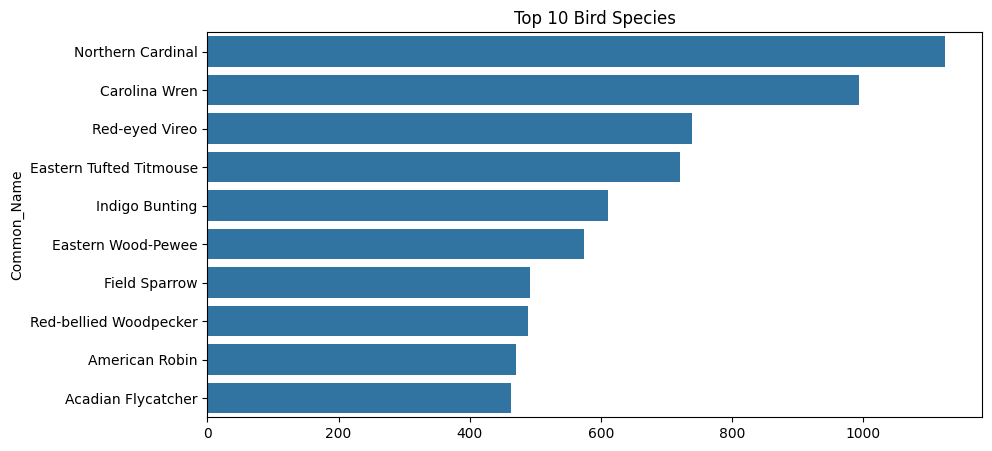

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_species.values, y=top_species.index)
plt.title("Top 10 Bird Species")
plt.show()

Habitat Comparison

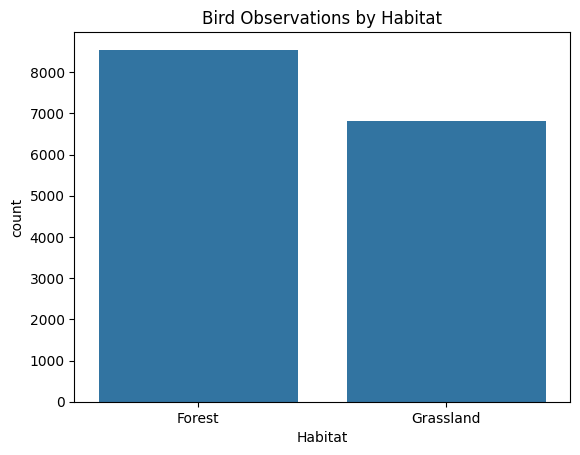

In [24]:
sns.countplot(x='Habitat', data=df)
plt.title("Bird Observations by Habitat")
plt.show()

Monthly Trend

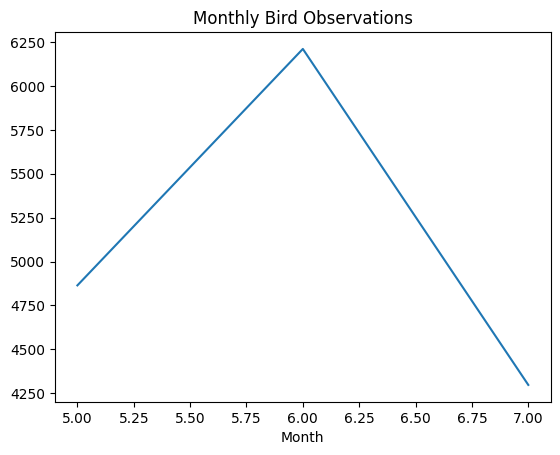

In [25]:
df.groupby('Month').size().plot(kind='line')
plt.title("Monthly Bird Observations")
plt.show()

Temperature vs Humidity

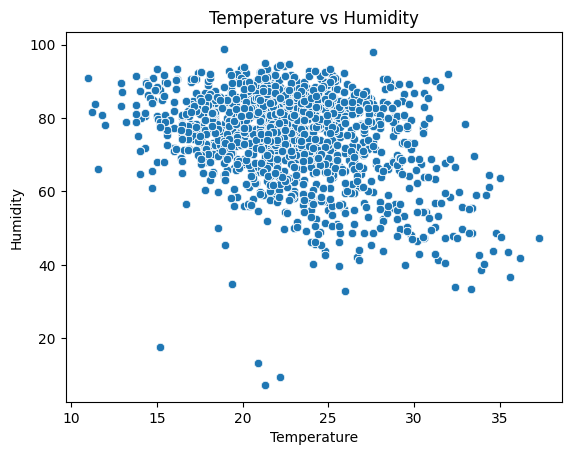

In [26]:
sns.scatterplot(x='Temperature', y='Humidity', data=df)
plt.title("Temperature vs Humidity")
plt.show()

**SPECIES ANALYSIS**

In [27]:
df['Scientific_Name'].nunique()


127

Watchlist Species

In [28]:
df['PIF_Watchlist_Status'].value_counts()

,count
PIF_Watchlist_Status,
False,14994
True,378


**CLEAN DATASET**

In [31]:
df.to_csv("bird_cleaned_data.csv", index=False)

In [33]:
files.download("bird_cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>